In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully")

Libraries loaded successfully


## Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\win 10\OneDrive\Desktop\Projects\smartcontainer-risk-engine\data\raw\container_shipments.csv")

In [3]:
df.head()

,Container_ID,Declaration_Date (YYYY-MM-DD),Declaration_Time,Trade_Regime (Import / Export / Transit),Origin_Country,Destination_Port,Destination_Country,HS_Code,Importer_ID,Exporter_ID,Declared_Value,Declared_Weight,Measured_Weight,Shipping_Line,Dwell_Time_Hours,Clearance_Status
0,97061800,2020-01-01,20:16:40,Import,BE,PORT_30,UG,440890,QLRUBN9,0VKY2BR,372254.40,108.0,106.510,LINE_MODE_10,37.6,Clear
1,85945189,2020-01-01,09:43:49,Import,CN,PORT_40,CA,690722,7JD1S2X,8WDKMC6,375751.20,11352.0,11541.578,LINE_MODE_40,51.7,Clear
2,77854751,2020-01-01,06:15:11,Import,CN,PORT_20,BA,620822,WI9O3I5,4DT3246,5353.02,20.7,20.404,LINE_MODE_40,31.3,Clear
3,46925060,2020-01-01,04:04:20,Import,VN,PORT_40,MN,940350,6LI9721,PKUOG2P,1477645.40,9218.0,8814.252,LINE_MODE_40,11.8,Clear
4,34131149,2020-01-01,03:36:29,Import,VN,PORT_20,LV,71080,RZ871V1,1HMVIVH,6364800.00,24000.0,24880.800,LINE_MODE_10,70.9,Clear


## Basic Understanding

In [4]:
df.shape

(54000, 16)

In [5]:
df.columns

Index(['Container_ID', 'Declaration_Date (YYYY-MM-DD)', 'Declaration_Time',
       'Trade_Regime (Import / Export / Transit)', 'Origin_Country',
       'Destination_Port', 'Destination_Country', 'HS_Code', 'Importer_ID',
       'Exporter_ID', 'Declared_Value', 'Declared_Weight', 'Measured_Weight',
       'Shipping_Line', 'Dwell_Time_Hours', 'Clearance_Status'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54000 entries, 0 to 53999
Data columns (total 16 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Container_ID                              54000 non-null  int64  
 1   Declaration_Date (YYYY-MM-DD)             54000 non-null  object 
 2   Declaration_Time                          54000 non-null  object 
 3   Trade_Regime (Import / Export / Transit)  54000 non-null  object 
 4   Origin_Country                            54000 non-null  object 
 5   Destination_Port                          54000 non-null  object 
 6   Destination_Country                       54000 non-null  object 
 7   HS_Code                                   54000 non-null  int64  
 8   Importer_ID                               54000 non-null  object 
 9   Exporter_ID                               54000 non-null  object 
 10  Declared_Value                    

In [7]:
df.describe()

,Container_ID,HS_Code,Declared_Value,Declared_Weight,Measured_Weight,Dwell_Time_Hours
count,5.400000e+04,54000.000000,5.400000e+04,5.400000e+04,5.400000e+04,54000.000000
mean,5.507171e+07,617202.735426,3.512241e+06,2.674132e+04,2.682208e+04,43.377954
std,2.596503e+07,261539.362851,5.405280e+07,6.659435e+05,6.675515e+05,25.661570
min,1.000019e+07,10129.000000,0.000000e+00,0.000000e+00,1.000000e-03,2.000000
25%,3.256710e+07,392690.000000,5.071350e+02,9.400000e+00,9.425000e+00,23.400000
50%,5.499228e+07,630790.000000,9.672000e+03,9.500000e+01,9.548200e+01,40.600000
75%,7.747199e+07,851829.000000,2.338245e+05,1.532000e+03,1.558095e+03,58.400000
max,9.999981e+07,970600.000000,7.045682e+09,6.002500e+07,6.195780e+07,189.500000


## Missing Value Analysis

In [8]:
missing = df.isnull().sum()

missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percent": missing_percent
})

missing_df.sort_values(by="Missing_Percent", ascending=False)

,Missing_Count,Missing_Percent
Container_ID,0,0.0
Declaration_Date (YYYY-MM-DD),0,0.0
Declaration_Time,0,0.0
Trade_Regime (Import / Export / Transit),0,0.0
Origin_Country,0,0.0
Destination_Port,0,0.0
Destination_Country,0,0.0
HS_Code,0,0.0
Importer_ID,0,0.0
Exporter_ID,0,0.0


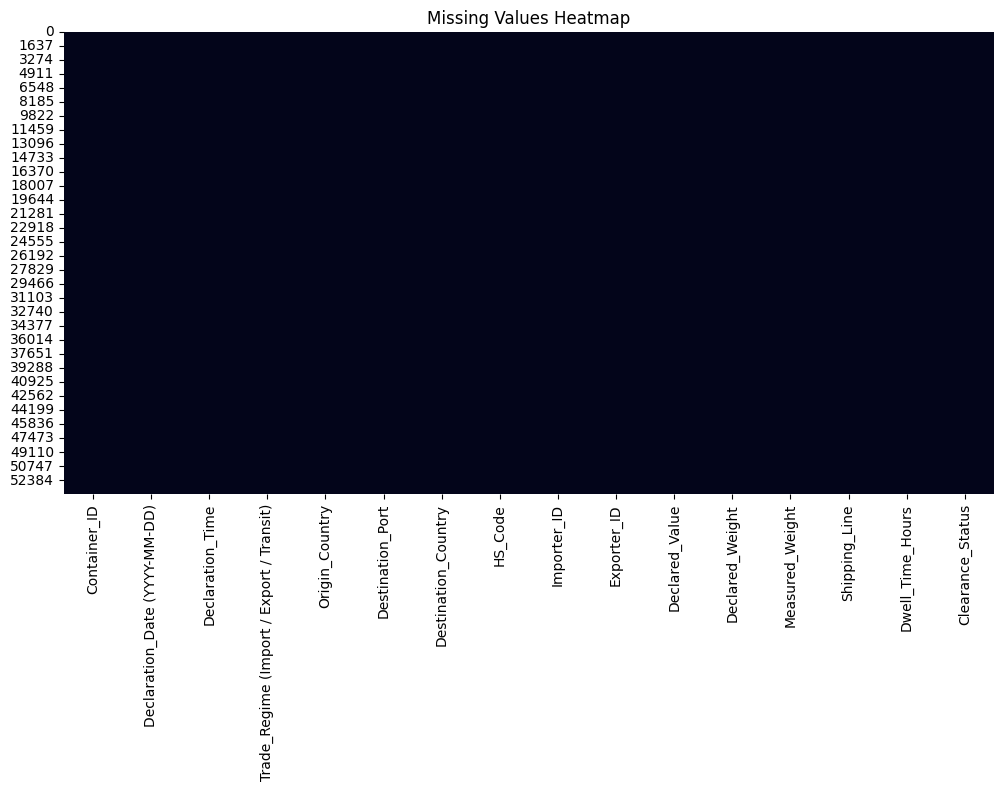

In [9]:
plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")

plt.show()

## Outlier Analysis

In [10]:
num_cols = df.select_dtypes(include=np.number).columns

num_cols

Index(['Container_ID', 'HS_Code', 'Declared_Value', 'Declared_Weight',
       'Measured_Weight', 'Dwell_Time_Hours'],
      dtype='object')

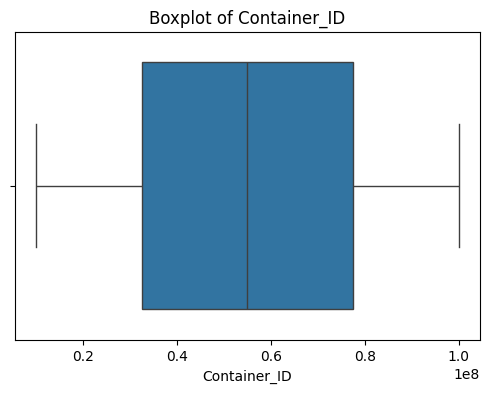

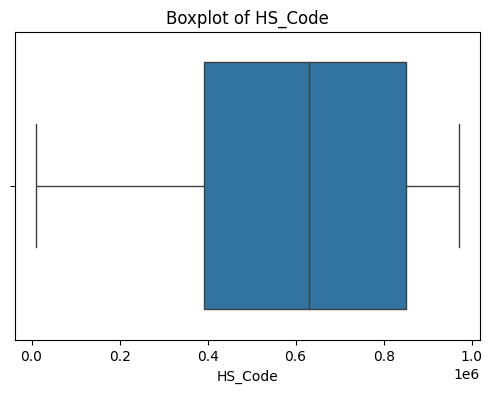

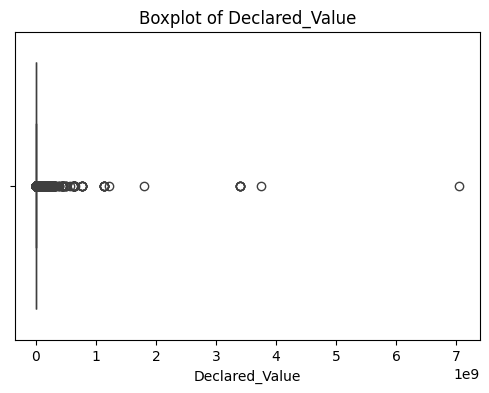

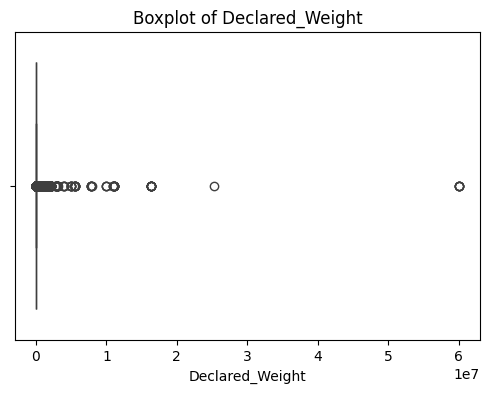

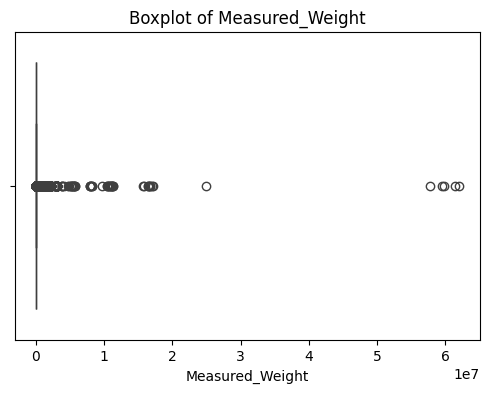

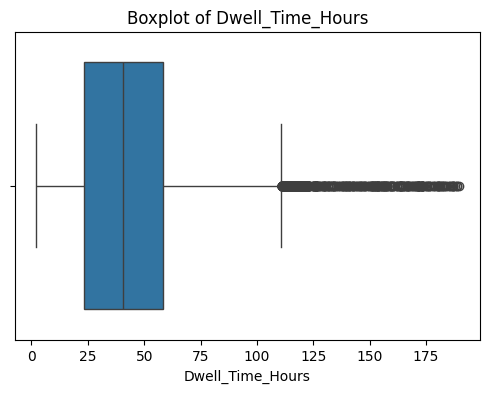

In [11]:
for col in num_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

## Correlation Analysis

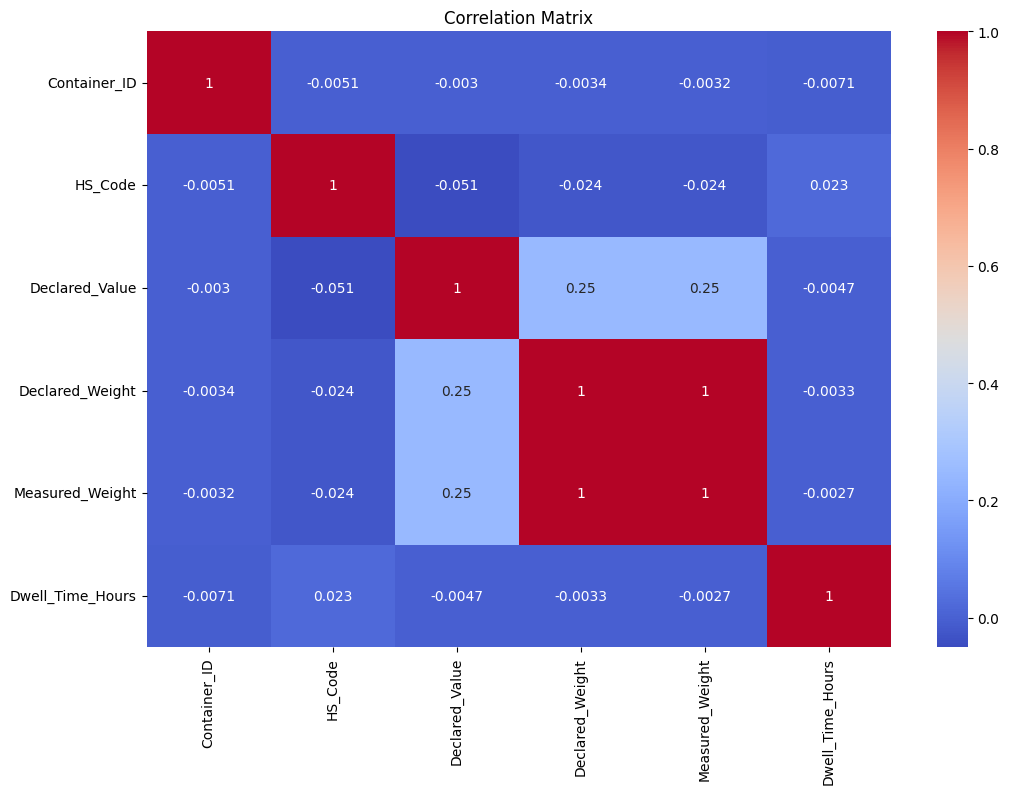

In [12]:
corr = df[num_cols].corr()

plt.figure(figsize=(12,8))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

# Initial Risk Assessment/Hypothesis

Based on the exploratory data analysis performed in `01_data_understanding.ipynb`, this document summarizes the initial operational and data-driven risk hypotheses for the SmartContainer Risk Engine project.

Source notebook: fileciteturn0file0

---

# 1. Dataset Overview

The shipment dataset contains:

* **54,000 container shipment records**
* **16 total features** including:

  * Container metadata
  * Trade regime information
  * Country and port details
  * Importer/exporter identifiers
  * Financial shipment values
  * Weight-related measurements
  * Clearance and dwell-time information

The dataset appears sufficiently large for:

* Supervised machine learning
* Anomaly detection
* Risk scoring systems
* Explainable AI pipelines

## Numerical Features Identified

The notebook identified the following numerical variables:

* `Container_ID`
* `HS_Code`
* `Declared_Value`
* `Declared_Weight`
* `Measured_Weight`
* `Dwell_Time_Hours`

These fields are expected to contribute significantly toward risk prediction.

---

# 2. Data Quality Assessment

## Missing Value Analysis

The missing value analysis indicates that the dataset contains:

* Negligible or no major missing-value issues
* Structurally complete shipment records
* Consistent schema across observations

### Risk Implication

This is operationally important because:

* Fewer imputations are required
* Model reliability improves
* Risk-scoring consistency increases
* Feature engineering becomes simpler and more trustworthy

### Potential Residual Risks

Even with low missingness, the following risks still exist:

| Risk                              | Description                                                                                                |
| --------------------------------- | ---------------------------------------------------------------------------------------------------------- |
| Hidden Null Semantics             | Placeholder values such as `0`, `Unknown`, or default IDs may still represent missing business information |
| Inconsistent Categorical Encoding | Country names, shipping lines, or clearance statuses may contain inconsistent formatting                   |
| Temporal Drift                    | Data collected over time may contain evolving trade patterns not visible in missing-value statistics       |

---

# 3. Statistical & Distribution-Based Risk Insights

## Declared Value Distribution

The descriptive statistics suggest that `Declared_Value` has:

* Very high variance
* Significant spread
* Extreme outliers

### Risk Hypothesis

Containers with unusually:

* High declared values
* Very low declared values
* Suspicious value distributions

may indicate:

* Under-invoicing
* Over-invoicing
* Tax evasion attempts
* Misdeclared goods
* Trade-based money laundering indicators

### Proposed Derived Risk Features

| Feature                      | Purpose                                |
| ---------------------------- | -------------------------------------- |
| Value Percentile Rank        | Identify unusually expensive shipments |
| Log Declared Value           | Stabilize skewed distribution          |
| Value Deviation Score        | Detect financial anomalies             |
| Country-wise Value Benchmark | Compare against expected trade norms   |

---

# 4. Weight Discrepancy Risk Assessment

## Declared vs Measured Weight

The dataset includes both:

* `Declared_Weight`
* `Measured_Weight`

This creates a critical opportunity for anomaly detection.

### Key Risk Hypothesis

Large differences between declared and measured weights may indicate:

* Cargo concealment
* Incorrect declarations
* Smuggling attempts
* Documentation fraud
* Dangerous goods misclassification

### Proposed Risk Features

| Feature                        | Formula / Logic                               |
| ------------------------------ | --------------------------------------------- |
| Weight Difference              | `Measured_Weight - Declared_Weight`           |
| Relative Weight Difference (%) | `(Difference / Declared_Weight) * 100`        |
| Weight Anomaly Flag            | Trigger if deviation exceeds threshold        |
| HS-Code Weight Consistency     | Compare against product-category expectations |

### Operational Risk Interpretation

Containers showing unusually high weight deviations should receive:

* Higher inspection priority
* Manual verification
* Secondary scanning
* Enhanced customs review

---

# 5. Dwell Time Risk Assessment

## Dwell_Time_Hours

The distribution analysis suggests the presence of extreme dwell-time values.

### Risk Hypothesis

Containers with unusually high dwell times may indicate:

* Customs clearance complications
* Incomplete documentation
* Regulatory issues
* Suspicious trade behavior
* Operational bottlenecks
* Fraud investigation holds

### Additional Business Interpretation

Long dwell durations may also reflect:

* High-risk shipping routes
* Importer compliance problems
* Repeated inspection history
* Port congestion anomalies

### Proposed Risk Features

| Feature                | Description                      |
| ---------------------- | -------------------------------- |
| Dwell Time Percentile  | Relative delay ranking           |
| Excessive Delay Flag   | Binary anomaly indicator         |
| Average Delay by Port  | Port-level operational benchmark |
| Importer Delay History | Behavioral profiling             |

---

# 6. Trade Regime Risk Hypothesis

The dataset includes:

* Import
* Export
* Transit

trade regimes.

### Initial Assumption

Different trade regimes likely carry different risk profiles.

### Example Risk Patterns

| Trade Regime | Potential Risk                                     |
| ------------ | -------------------------------------------------- |
| Transit      | Route diversion or concealed destination risks     |
| Import       | Under-valuation and customs duty evasion           |
| Export       | Misclassification or export restriction violations |

### Proposed Modeling Strategy

* Encode trade regime categorically
* Learn regime-specific anomaly behavior
* Build segment-level risk distributions

---

# 7. Country & Route-Based Risk Assessment

The dataset contains:

* Origin country
* Destination country
* Destination port

### Risk Hypothesis

Some routes may historically demonstrate:

* Higher fraud rates
* Abnormal shipment patterns
* Sanction-sensitive trade activity
* Repeated inspection failures

### Potential Features

| Feature                       | Purpose                          |
| ----------------------------- | -------------------------------- |
| Country Risk Score            | Historical trade risk benchmark  |
| Port Congestion Score         | Operational anomaly indicator    |
| Route Frequency Analysis      | Detect uncommon shipping paths   |
| Importer-Country Relationship | Behavioral consistency profiling |

---

# 8. Behavioral Risk Assessment

The presence of:

* `Importer_ID`
* `Exporter_ID`
* `Shipping_Line`

allows for behavioral anomaly modeling.

### Risk Hypothesis

Repeated abnormal behavior from the same entities may indicate:

* Organized fraud patterns
* Shell trading networks
* Repeated documentation inconsistencies
* Coordinated smuggling behavior

### Proposed Behavioral Features

| Feature                 | Description                    |
| ----------------------- | ------------------------------ |
| Historical Risk Average | Mean historical shipment risk  |
| Shipment Frequency      | Number of shipments over time  |
| Entity Risk Volatility  | Behavioral instability measure |
| First-Time Trader Flag  | Detect unknown entities        |

---

# 9. Outlier Analysis Summary

The boxplot analysis identified strong outlier presence across several numerical features.

### Interpretation

Outliers are expected in real-world customs and logistics systems because:

* Trade volumes vary significantly
* High-value industrial shipments exist
* Some ports process specialized cargo

However, certain outliers may represent:

* Fraudulent declarations
* Data entry errors
* Smuggling indicators
* Compliance violations

### Important Modeling Note

Outliers should **not automatically be removed**.

Instead:

* Investigate them carefully
* Use robust scaling techniques
* Combine statistical and domain-aware anomaly detection
* Convert extreme deviations into risk signals

---

# 10. Correlation Analysis Findings

The correlation matrix helps identify relationships between numerical variables.

### Initial Interpretation

Potential correlations may exist between:

* Declared value and weight
* Dwell time and clearance behavior
* Measured weight and declared weight

### Risk Engineering Opportunity

Unexpected deviations from normal correlations can indicate suspicious behavior.

Example:

* Extremely high value with very low weight
* High weight with unusually low declared value
* Long dwell time with low-value cargo

These patterns can become engineered anomaly features.

---

# 11. Initial Risk Scoring Logic (Proposed)

An initial hybrid risk score can combine:

| Component          | Weight (Initial Estimate) |
| ------------------ | ------------------------- |
| Weight discrepancy | 30%                       |
| Value anomaly      | 25%                       |
| Dwell time anomaly | 20%                       |
| Route/country risk | 15%                       |
| Behavioral risk    | 10%                       |

## Example Formula

```text
Risk Score =
0.30 × Weight_Anomaly
+ 0.25 × Value_Anomaly
+ 0.20 × Dwell_Time_Risk
+ 0.15 × Route_Risk
+ 0.10 × Behavioral_Risk
```

The final production system may later replace this heuristic logic with:

* Supervised ML models
* Ensemble methods
* Isolation Forest
* Autoencoders
* Graph-based anomaly detection

---

# 12. Initial Model Recommendations

## Recommended Baseline Models

### Supervised Models

* Logistic Regression
* Random Forest
* XGBoost
* LightGBM

### Unsupervised / Anomaly Models

* Isolation Forest
* One-Class SVM
* Local Outlier Factor
* Autoencoder-based anomaly detection

### Explainability Tools

* SHAP
* Feature importance ranking
* Rule-based explanations

---

# 13. Explainability Strategy

The hackathon explicitly requires explainability.

Example explanation outputs:

| Risk Level | Explanation                                                                        |
| ---------- | ---------------------------------------------------------------------------------- |
| Critical   | "Measured weight exceeded declared weight by 42%, with unusually long dwell time." |
| Medium     | "Shipment route historically shows elevated inspection rates."                     |
| Low        | "Container characteristics align with normal trade behavior."                      |

---

# 14. Initial Conclusions

The exploratory analysis indicates that the dataset is highly suitable for building:

* A real-world AI risk engine
* Explainable anomaly detection systems
* Behavioral trade intelligence models
* Hybrid rule-based + ML fraud detection pipelines

The strongest early indicators of shipment risk appear to be:

1. Weight discrepancies
2. Declared value anomalies
3. Excessive dwell times
4. Route irregularities
5. Repeated behavioral anomalies from entities

These insights will guide:

* Feature engineering
* Risk scoring design
* Model selection
* Explainability implementation
* Dashboard analytics

---

# 15. Recommended Next Steps

## Immediate Priorities

1. Data cleaning and schema normalization
2. Feature engineering for anomaly indicators
3. Risk label generation strategy
4. Baseline anomaly detection pipeline
5. Supervised model experimentation
6. Explainability integration using SHAP
7. Risk dashboard development

## Engineering Recommendations

* Use modular ML pipelines
* Track experiments using MLflow
* Add data validation checks
* Create reusable preprocessing modules
* Maintain production-ready architecture from the beginning

---

# Appendix — Notebook Observations

The notebook currently includes:

* Dataset loading
* Shape analysis
* Schema inspection
* Descriptive statistics
* Missing-value analysis
* Outlier visualization using boxplots
* Correlation heatmap generation

These outputs form the foundation for the full SmartContainer Risk Engine pipeline.

Reference notebook: fileciteturn0file0
